# Red Convolucional - CIFAR-10

3 modelos distintos con CNN.
CIFAR-10 tiene 60,000 imagenes a color 32x32. Distribuidas en 10 categorias: avion, automovil, pajaro, gato, ciervo, perro, rana, caballo, barco y camion.

In [33]:
import torch
import torch.nn as nn #capas de redes neuronales 
from torch.optim import Adam, SGD
from torch.utils.data import DataLoader #Divide el dataset en mini-batches
import torchvision #CIFAR-10
import torchvision.transforms as transforms #Herramientas para preprocesar/convertir las imágenes
import matplotlib.pyplot as plt
from tqdm import tqdm

In [34]:
#Buscaremos si tenemos GPU NIVIDIA, de no ser asi utilizaremos el CPU de respaldo

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


## 1. Carga y preprocesamiento del Dataset

In [35]:
# Transformamos las imagenes a tensores y normalizamos
transform = transforms.Compose([
    transforms.ToTensor(), # imagen PIL a Pytorch, [0,1] 
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616]) #media real del dataset CIFAR-10 
])

# Entrenamos y Descarga
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Creamos dataset de prueba
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"Imagenes de entrenamiento: {len(train_dataset)}")
print(f"Imagenes de prueba: {len(test_dataset)}")

Files already downloaded and verified
Files already downloaded and verified
Imagenes de entrenamiento: 50000
Imagenes de prueba: 10000


## 2. DataLoaders - División en mini-barches

In [36]:
class_names = ['avion', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Batches en train: {len(train_loader)}")
print(f"Batches en test:  {len(test_loader)}")

Batch size: 64
Batches en train: 782
Batches en test:  157


## 3. Funciones de entrenamiento y evaluación


In [37]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1)
    correct = pred.eq(y).sum().item()
    return correct / N

In [38]:
def train(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': []
    }

    for epoch in tqdm(range(num_epochs), desc="Entrenando", unit="época"):

        # Entrenamiento
        model.train()
        train_loss = 0.0 
        train_acc = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad() #Limpiamos los gradientes
            outputs = model(X_batch) #Forward pass
            loss = criterion(outputs, y_batch) # Calculamos perdida
            loss. backward() # Cambiar cada peso para reducir el error
            optimizer.step() #Actualizamos pesos

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(train_loader.dataset))

        # Evaluación
        model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for X_test, y_test in test_loader:
                X_test = X_test.to(device)
                y_test = y_test.to(device)

                test_outputs = model(X_test)
                test_loss += criterion(test_outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(test_outputs, y_test, len(test_loader.dataset))

        #Guardamos la metricas
        history['train_loss'].append(train_loss / len(train_loader.dataset))
        history['test_loss'].append(test_loss / len(test_loader.dataset))
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    return history

## 4. Arquitecuras CNN

In [39]:
# Modelo 1
model1 = nn.Sequential(
    
    nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                           # 32 x 16 x 16

    
    nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                           # 64 x 8 x 8

    
    nn.Flatten(),                                 # 64*8*8 = 4096
    nn.Linear(4096, 512),
    nn.ReLU(),
    nn.Linear(512, 10)                            # 10 clases
).to(device)

print("Modelo 1 - CNN Simple")
print(model1)


Modelo 1 - CNN Simple
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=4096, out_features=512, bias=True)
  (8): ReLU()
  (9): Linear(in_features=512, out_features=10, bias=True)
)


In [40]:
# Modelo 2:
model2 = nn.Sequential(
    
    nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 32 x 16 x 16

    
    nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 64 x 8 x 8

    
    nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 128 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 128 x 4 x 4


    nn.Flatten(),                                  # 128*4*4 = 2048
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 10)                             # 10 clases
).to(device)

print("Modelo 2 - CNN Profunda")
print(model2)


Modelo 2 - CNN Profunda
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=2048, out_features=512, bias=True)
  (11): ReLU()
  (12): Dropout(p=0.3, inplace=False)
  (13): Linear(in_features=512, out_features=10, bias=True)
)


In [41]:
# Modelo 3:
model3 = nn.Sequential(
    
    nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32 x 32 x 32
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 32 x 16 x 16

    
    nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 64 x 16 x 16
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 64 x 8 x 8

    
    nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 128 x 8 x 8
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                            # 128 x 4 x 4

    
    nn.Flatten(),                                  # 128*4*4 = 2048
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 10)                             # 10 clases
).to(device)

print("Modelo 3 - CNN con BatchNorm")
print(model3)


Modelo 3 - CNN con BatchNorm
Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=2048, out_features=512, bias=True)
  (14): ReLU()
  (15): Dropout(p=0.3, inplace=False)
  (16): Linear(in_features=512, 

## 5. Entrenamiento

In [42]:
# Estos valores son IGUALES para los 3 modelos
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
criterion = nn.CrossEntropyLoss() #softmax y log loss

In [43]:
print("Entrenando Modelo 1 - Simple")

optimizer1 = Adam(model1.parameters(), lr=LEARNING_RATE)
history1 = train(model1, train_loader, test_loader, criterion, optimizer1, NUM_EPOCHS)


Entrenando Modelo 1 - Simple


Entrenando: 100%|██████████| 15/15 [03:48<00:00, 15.25s/época]


In [44]:
print("Entrenando Modelo 2 - Con Dropout")

optimizer2 = Adam(model2.parameters(), lr=LEARNING_RATE)
history2 = train(model2, train_loader, test_loader, criterion, optimizer2, NUM_EPOCHS)


Entrenando Modelo 2 - Con Dropout


Entrenando: 100%|██████████| 15/15 [03:49<00:00, 15.29s/época]


In [45]:
print("Entrenando Modelo 3 - Con Dropout y BatchNorm")


optimizer3 = Adam(model3.parameters(), lr=LEARNING_RATE)
history3 = train(model3, train_loader, test_loader, criterion, optimizer3, NUM_EPOCHS)


Entrenando Modelo 3 - Con Dropout y BatchNorm


Entrenando: 100%|██████████| 15/15 [03:51<00:00, 15.45s/época]


## 6. Analisis

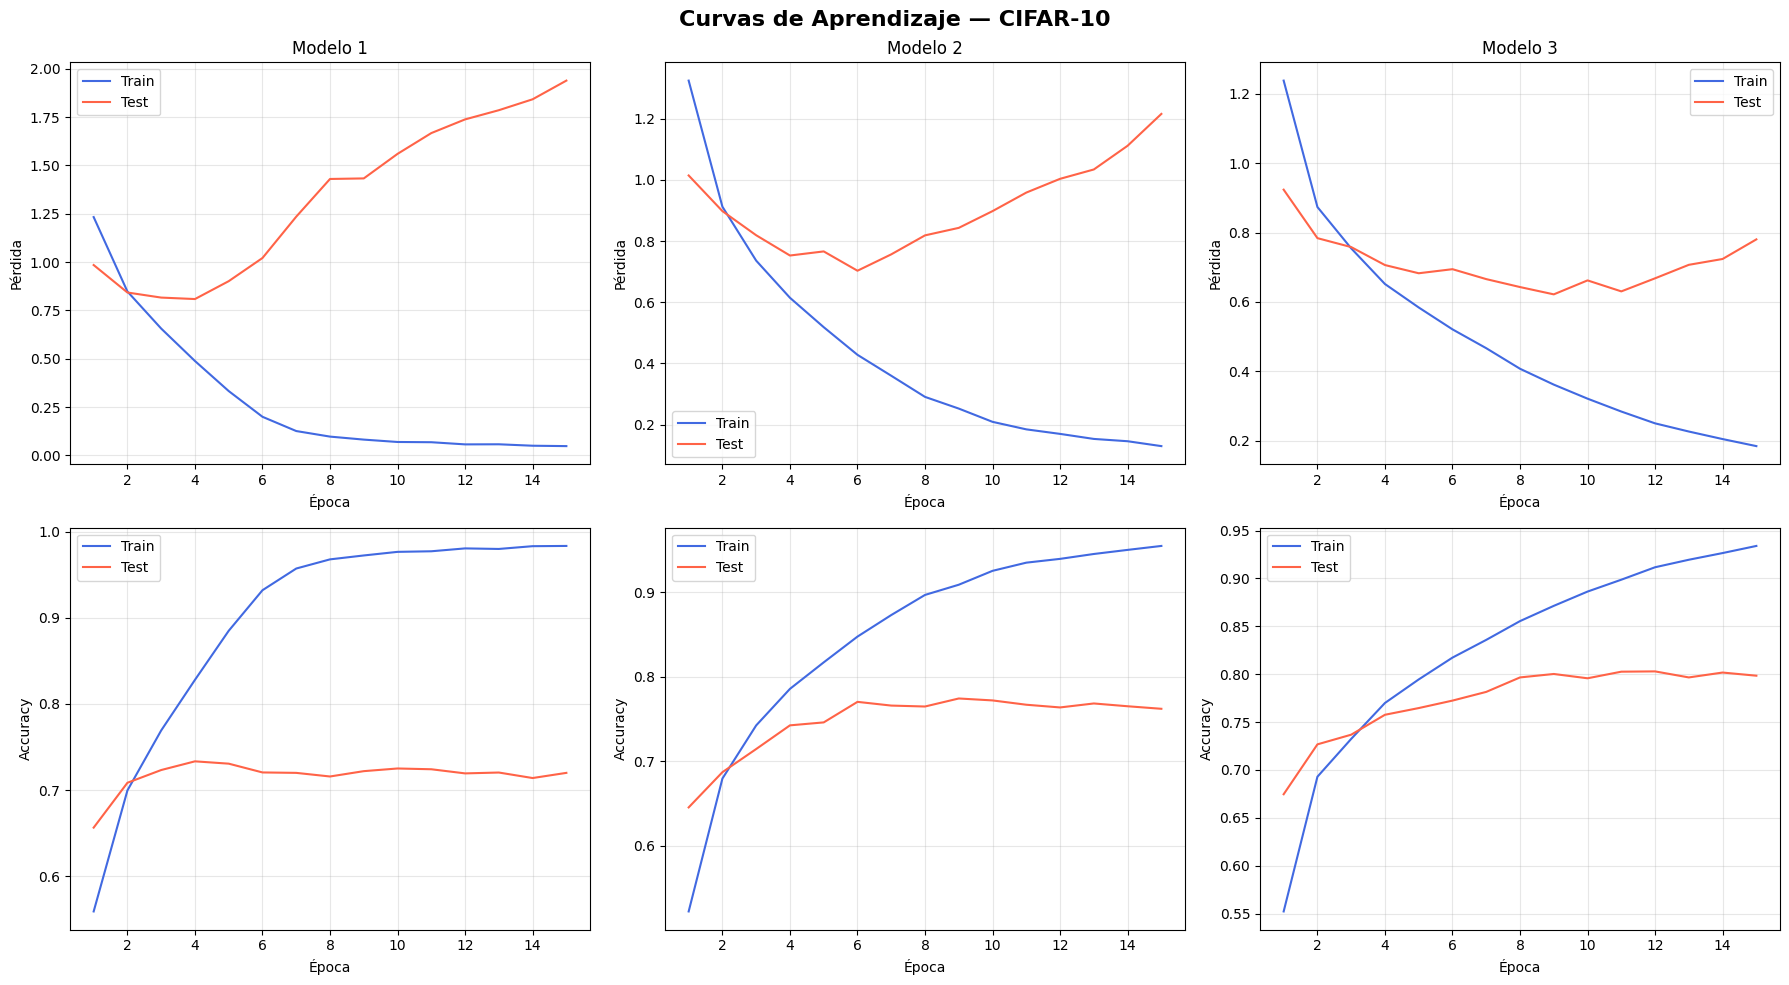

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas de Aprendizaje — CIFAR-10', fontsize=16, fontweight='bold')

modelos = [
    (history1, 'Modelo 1'),
    (history2, 'Modelo 2'),
    (history3, 'Modelo 3'),
]

epochs_range = range(1, NUM_EPOCHS + 1)

for col, (history, nombre) in enumerate(modelos):

    # ── Gráfica de pérdida 
    axes[0, col].plot(epochs_range, history['train_loss'], label='Train', color='royalblue')
    axes[0, col].plot(epochs_range, history['test_loss'],  label='Test',  color='tomato')
    axes[0, col].set_title(nombre)
    axes[0, col].set_xlabel('Época')
    axes[0, col].set_ylabel('Pérdida')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    # ── Gráfica de accuracy
    axes[1, col].plot(epochs_range, history['train_acc'], label='Train', color='royalblue')
    axes[1, col].plot(epochs_range, history['test_acc'],  label='Test',  color='tomato')
    axes[1, col].set_xlabel('Época')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Evaluación del mejor modelo

In [47]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            predicted = outputs.argmax(dim=1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    accuracy = correct / total
    return accuracy

acc1 = evaluate(model1, test_loader)
acc2 = evaluate(model2, test_loader)
acc3 = evaluate(model3, test_loader)

print(f"Modelo 1:  {acc1*100:.2f}%")
print(f"Modelo 2:  {acc2*100:.2f}%")
print(f"Modelo 3:  {acc3*100:.2f}%")
print(f"\nMejor modelo: Modelo 3 con {acc3*100:.2f}% de accuracy en test")


Modelo 1:  71.99%
Modelo 2:  76.19%
Modelo 3:  79.84%

Mejor modelo: Modelo 3 con 79.84% de accuracy en test


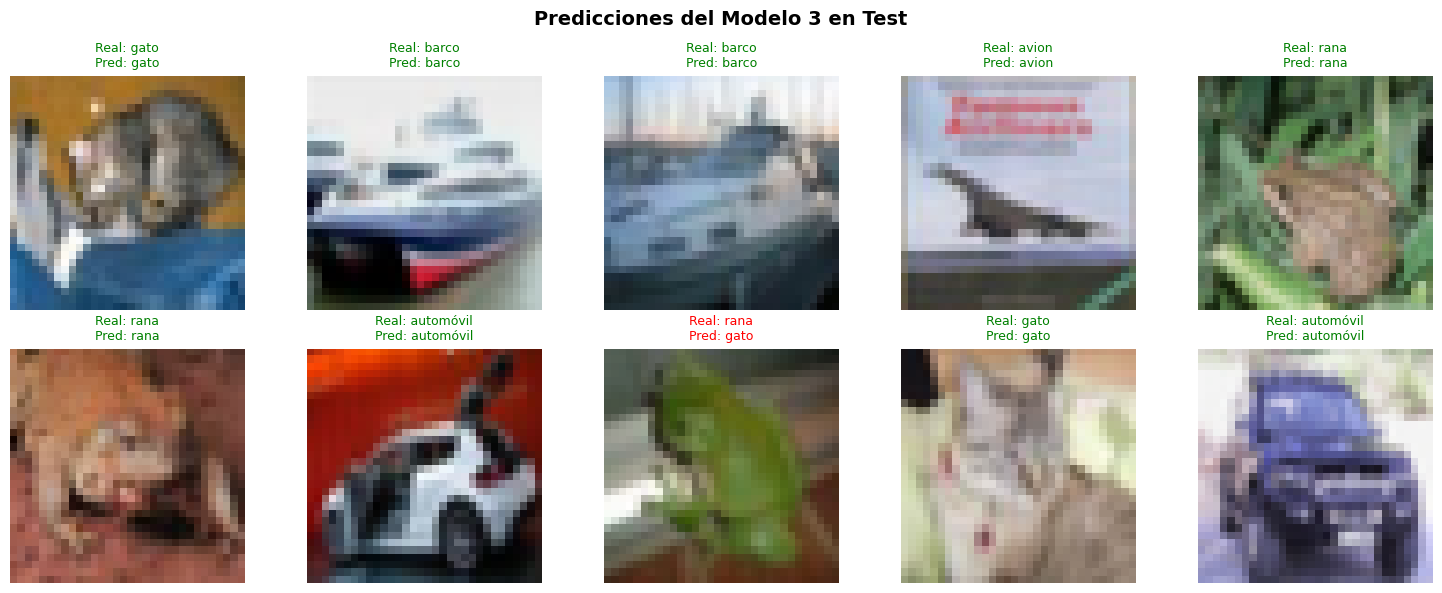

In [48]:
# Mostrar 10 imágenes con predicción vs etiqueta real
model3.eval()

# Valores para "desnormalizar" la imagen y poder verla bien
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2470, 0.2435, 0.2616]

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model3(images)
    predictions = outputs.argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Predicciones del Modelo 3 en Test', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = (img * std) + mean          # desnormalizar
    img = img.clip(0, 1)

    real  = class_names[labels[i].item()]
    pred  = class_names[predictions[i].item()]
    color = 'green' if real == pred else 'red'

    ax.imshow(img)
    ax.set_title(f'Real: {real}\nPred: {pred}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Imagen Propia

In [49]:
from PIL import Image

def clasificar_imagen(ruta_imagen):

    # Transformaciones consistentes con el entrenamiento
    transform_usuario = transforms.Compose([
        transforms.Resize((32, 32)),      # Redimensionar a 32x32
        transforms.ToTensor(),            # Convertir a tensor [0,1]
        transforms.Normalize(             # Misma normalización del entrenamiento
            mean=[0.4914, 0.4822, 0.4465],
            std=[0.2470, 0.2435, 0.2616]
        )
    ])

    # Cargar y preprocesar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')  # Forzar 3 canales
    img_tensor = transform_usuario(img_original)            # Aplicar transforms
    img_tensor = img_tensor.unsqueeze(0).to(device)        # Agregar dimensión de batch

    # Clasificar con el mejor modelo
    model3.eval()
    with torch.no_grad():
        output = model3(img_tensor)
        pred_idx = output.argmax(dim=1).item()
        etiqueta = class_names[pred_idx]

    # Mostrar imagen y resultado
    plt.figure(figsize=(4, 4))
    plt.imshow(img_original)
    plt.title(f'Predicción: {etiqueta}', fontsize=14, fontweight='bold', color='royalblue')
    plt.axis('off')
    plt.show()

    return etiqueta


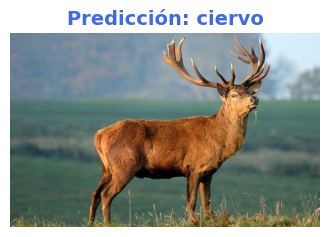


Etiqueta predicha: ciervo


In [50]:
# Descargamos una imagen de un Ciervo

resultado = clasificar_imagen("./PruebaPropia.jpg")
print(f"\nEtiqueta predicha: {resultado}")


## 9. Reflexión Personal

Podemos ver como con una red simple (modelo 1) simplemente memoriza las imagenes y es por eso que en entrenamiento tiene una muy buena acurrancy pero en los de testo es es totalmente diferente, por lo que podemos declarar que este cuenta con overfitting. Ya en el modelo 2 se agregó el Dropout para apagar un porcentaje de las neuronas y esto si ayudo a reducir el overfitting que tenia el primer modelo, pero aun asi cuenta con un poco de ello por lo cual no es bueno. Ya en el modelo 3 agregamos el Batch Normalization apesar del Dropout. Esto ayudó a que la red si aprendiera y no memorice.